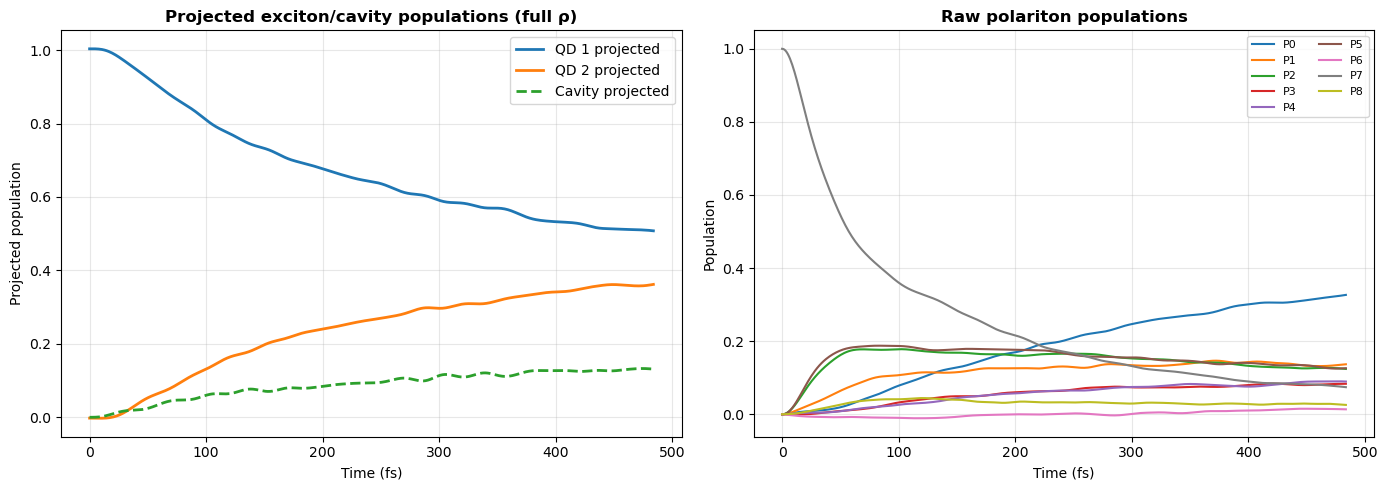

Polariton energies (eV, shifted by lowest):
  P0: 0.00000000
  P1: 0.04771981
  P2: 0.05153155
  P3: 0.05153155
  P4: 0.05184545
  P5: 0.05184545
  P6: 0.09864290
  P7: 0.09864290
  P8: 0.11477791

Max projected exciton/cavity populations (full ρ):
  QD 1: 1.00366
  QD 2: 0.361564
  Cavity: 0.1323

Mean total projected population: 1
Max |full-ρ - pop-only projection|: 2.075e-02


In [1]:
#!/usr/bin/env python3
"""
Read polaritonic-basis dynamics from pop.out / rho.npz and project onto the
exciton/cavity basis using the full density matrix (including coherences):

    rho_ex(t) = U rho_pol(t) U^H

State ordering in the exciton/cavity basis:
- States 0-3: QD 1 exciton states
- States 4-7: QD 2 exciton states
- State 8: cavity photon state
"""

import os
import numpy as np
import matplotlib.pyplot as plt

autos = 2.4188843265857e-17
au_to_eV = 27.2114079527
n_qd = 2
nstate_per_qd = 4
n_cavity = 1
n_qd_states = n_qd * nstate_per_qd
n_exciton_states = n_qd_states + n_cavity


def qd_cavity_totals(pop):
    qd_total = np.zeros((pop.shape[0], n_qd))
    for qd in range(n_qd):
        start = qd * nstate_per_qd
        end = (qd + 1) * nstate_per_qd
        qd_total[:, qd] = pop[:, start:end].sum(axis=1)
    cavity = pop[:, n_qd_states]
    return qd_total, cavity


data = np.loadtxt("pop.out")
time = data[:, 0] * autos * 1e15  # au to fs
polariton_pop = data[:, 1:]
n_states = polariton_pop.shape[1]

if n_states != n_exciton_states:
    raise ValueError(f"Expected {n_exciton_states} states, found {n_states}")

if not os.path.exists("rho.npz"):
    raise FileNotFoundError("Missing rho.npz. Re-run mash.py with -rho.")

transform = np.load("polariton_transform_AU.npz", allow_pickle=True)
U = transform["exciton_to_polariton_U"]
polariton_energies_AU = transform["polariton_energies_AU"]
state_labels = transform["exciton_state_labels"] if "exciton_state_labels" in transform.files else None

if U.shape != (n_exciton_states, n_exciton_states):
    raise ValueError(f"Unexpected transformation matrix shape {U.shape}")

rhoz = np.load("rho.npz")
rho_pol = rhoz["rho_re"] + 1j * rhoz["rho_im"]
time_rho = rhoz["time"] * autos * 1e15

# Full unitary projection including polariton coherences
rho_ex = np.einsum("ia,tab,jb->tij", U, rho_pol, np.conj(U))
exciton_projected_pop = np.real(np.diagonal(rho_ex, axis1=1, axis2=2))
exciton_projected_pop_poponly = polariton_pop @ (np.abs(U) ** 2).T

qd_total_pop, cavity_pop = qd_cavity_totals(exciton_projected_pop)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for qd in range(n_qd):
    ax.plot(time_rho, qd_total_pop[:, qd], label=f"QD {qd + 1} projected", linewidth=2)
ax.plot(time_rho, cavity_pop, label="Cavity projected", linewidth=2, linestyle="--")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Projected population")
ax.set_title("Projected exciton/cavity populations (full ρ)", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
for state in range(n_states):
    ax.plot(time, polariton_pop[:, state], label=f"P{state}", linewidth=1.5)
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Population")
ax.set_title("Raw polariton populations", fontsize=12, fontweight="bold")
ax.legend(ncol=2, fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Polariton energies (eV, shifted by lowest):")
energies_eV = (polariton_energies_AU - polariton_energies_AU.min()) * au_to_eV
for state, energy in enumerate(energies_eV):
    print(f"  P{state}: {energy:.8f}")

print("\nMax projected exciton/cavity populations (full ρ):")
for qd in range(n_qd):
    print(f"  QD {qd + 1}: {qd_total_pop[:, qd].max():.6g}")
print(f"  Cavity: {cavity_pop.max():.6g}")
print(f"\nMean total projected population: {exciton_projected_pop.sum(axis=1).mean():.6g}")
print(f"Max |full-ρ - pop-only projection|: {np.max(np.abs(exciton_projected_pop - exciton_projected_pop_poponly)):.3e}")


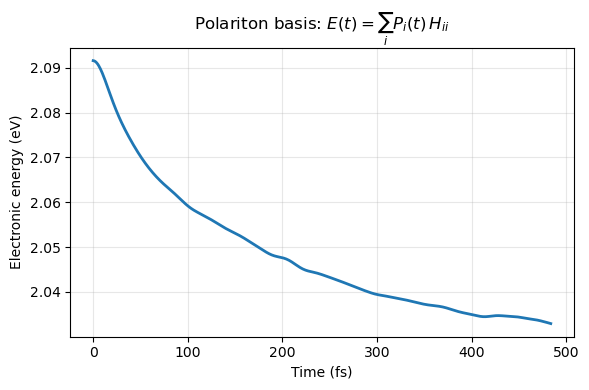

E(0)  = 2.091585 eV
E(end)= 2.032941 eV
ΔE    = -58.644 meV


In [2]:
#!/usr/bin/env python3
"""
Electronic energy relaxation in the polariton basis.
"""

import numpy as np
import matplotlib.pyplot as plt

autoev = 27.2114079527

params = np.load("lvc_params_AU.npz")
ham_sys_AU = np.real(params["ham_sys_AU"])
E_diag_eV = np.diag(ham_sys_AU) * autoev

E_t_eV = polariton_pop @ E_diag_eV
dE_meV = (E_t_eV - E_t_eV[0]) * 1e3

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(time, E_t_eV, linewidth=2, color="C0")
ax.set_xlabel("Time (fs)")
ax.set_ylabel("Electronic energy (eV)")
ax.set_title(r"Polariton basis: $E(t)=\sum_i P_i(t)\,H_{ii}$")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"E(0)  = {E_t_eV[0]:.6f} eV")
print(f"E(end)= {E_t_eV[-1]:.6f} eV")
print(f"ΔE    = {dE_meV[-1]:.3f} meV")
